<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Machine Learning 기계학습
학습 Learning: 추정(estimation)

Statistical learning 통계적 학습

$y$  가 있는 경우(label 이 있는 경우): 지도학습(supervised learning)

$y$  가 없는 경우(label 이 없는 경우): 비지도학습(unsupervised learning)

${x_i,y_i}$  가 주어졌을 때,  $x$ 를 이용해서  $y$ 를 예측하는 문제

$y$ 가 연속확률변수인 경우에는 회귀모형을 사용하고,

$y$ 가 이산확률변수인 경우에는 분류모형(classification)을 사용함

조건부기대함수(conditional expectation function)를 이용함

주어진  $x$ 의 근방에서  $y$ 의 평균을 계산하는 것임
선형모형을 가정하는 것은 강하지만 유용한 가정임
훈련(추정)을 어떻게 하냐? OLS를 이용해서 함

평균제곱오차(mean squared-error, MSE)를 모형이 좋은지에 대한 기준으로 사용(goodness of fit)

모형이 복잡해진다고해서 늘 좋은 것은 아님

편향-분산 상충관계(Bias-Variance trade-off)가 존재함

정확하게 할려고 하면 커지고, 분산을 줄일려고 하면 부정확해짐

$x0$ 에서  $y0$ 를 예측하는 모형의 오차

$$
y_0−\hat{f}(x_0)=(f(x_0)+ϵ)−\hat{f}(x_0)=(f(x_0)−\hat{f}(x_0))+ϵ
$$

$$
E(y_0−\hat{f}(x_0))^2=E(f(x_0)−\hat{f}(x_0))^2+2E(f(x_0)−\hat{f}(x_0))ϵ+Eϵ^2
$$

$$
E(f(x_0)−\hat{f}(x_0))^2=Var(\hat{f}(x_0))+Bias(\hat{f}(x_0))^2
$$

$$
E(y_0−\hat{f}(x_0))^2=Var(\hat{f}(x_0))+Bias(\hat{f}(x_0))^2+Var(ϵ)
$$




In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load the dataset
boston = pd.read_csv('/content/Boston.csv')

boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [ ]:
# Define X and y
y = boston['medv']  # target, depedent variables
X = boston.drop(['medv','Unnamed: 0'], axis=1) # features

# train/test data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# features 를 늘려가면서 MSE 가 어떻게 변하는지를 본다
# train과 test에서 각각 어떻게 변하는지

selected_features = ['rm','lstat','ptratio','nox','dis','crim','age','tax']

mse_train = []
mse_test = []
feature_sets = []

current_features = []

for feature in selected_features:
    current_features.append(feature)

    X_train_subset = X_train[current_features]
    X_test_subset = X_test[current_features]

    # train model
    model = LinearRegression()
    model.fit(X_train_subset, y_train)

    # predict and calculate MSE for test data
    y_pred_test = model.predict(X_test_subset)
    mse_test.append(mean_squared_error(y_test, y_pred_test))

    # predict and calculate MSE for train data
    y_pred_train = model.predict(X_train_subset)
    mse_train.append(mean_squared_error(y_train, y_pred_train))

    feature_sets.append(current_features.copy())

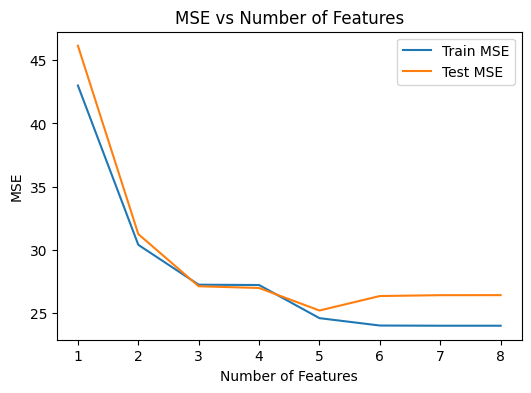

In [ ]:
# visualize MSE against number of features
plt.figure(figsize=(6, 4))

plt.plot(range(1, len(mse_train) + 1), mse_train, label='Train MSE')
plt.plot(range(1, len(mse_test) + 1), mse_test, label='Test MSE')

plt.xlabel('Number of Features')
plt.ylabel('MSE')
plt.title('MSE vs Number of Features')
plt.legend()
plt.show()

### 정규화(reularization) 혹은 축소기법(shrinkage method)

- 특성변수가 아주 많을 때,
- 특성변수 중 일부를 임의로 선택하거나
- 체계적으로 선택함(subset selection, forward 혹은 backward)

- 계수의 추정치를 제한(constrain)
- 계수의 추정값을 축소(shrink): 0으로 만들거나, 0에 가깝게 만들거나

- Ridge regression/Lasso regression 이 있음(복합 elastic net)

- Least sqaure
$$
\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_{1i} - \cdots - \beta_k x_{ki})^2
$$

- Penalized regression(Ridge regression 능선회귀)
$$
\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_{1i} - \cdots - \beta_k x_{ki})^2 + \lambda \sum \beta_i^2
$$


- Penalized regression(Lasso regression 올가미 회귀)
$$
\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_{1i} - \cdots - \beta_k x_{ki})^2 + \lambda \sum |\beta_i|
$$



































- $\lambda$를 정해야 하는데,
- $\lambda = 0$ -> OLS 모형이 됨
- $\lambda = \infty $ -> 모든 계수가 0이 됨

- 실제 $\lambda$는 이 사이에 있을 것이고, cross-validation(CV, 교차검증)을 통해서 정하는 것이 보통임




In [ ]:
import pandas as pd


Hitters = pd.read_csv('/content/Hitters.csv')


In [ ]:
# data cleaning(pre-processing  전처리)

# 결측치 버림
Hitters = Hitters.dropna()
Hitters.head()

# one-hot-encoding
df = pd.get_dummies(Hitters, drop_first=True)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


In [ ]:
# target: salary
# featrues: salary 빼고 다

y = df['Salary']
X = df.drop(columns=['Salary'])

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [ ]:
# train/test data split





